In [19]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


In [20]:
anime = pd.read_csv("anime.csv")
ratings = pd.read_csv("rating.csv")

In [21]:
# Basic info
print(anime.head())
print(anime.info())


print("anime:",anime.shape)
print("rating:",ratings.shape)

   anime_id                              name  \
0     32281                    Kimi no Na wa.   
1      5114  Fullmetal Alchemist: Brotherhood   
2     28977                          Gintama°   
3      9253                       Steins;Gate   
4      9969                     Gintama&#039;   

                                               genre   type episodes  rating  \
0               Drama, Romance, School, Supernatural  Movie        1    9.37   
1  Action, Adventure, Drama, Fantasy, Magic, Mili...     TV       64    9.26   
2  Action, Comedy, Historical, Parody, Samurai, S...     TV       51    9.25   
3                                   Sci-Fi, Thriller     TV       24    9.17   
4  Action, Comedy, Historical, Parody, Samurai, S...     TV       51    9.16   

   members  
0   200630  
1   793665  
2   114262  
3   673572  
4   151266  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  

In [22]:
# merge both the tables
df = ratings.merge(anime, on='anime_id', how='left')
print(df.shape)
display(df.head())


(7813737, 9)


,user_id,anime_id,rating_x,name,genre,type,episodes,rating_y,members
0,1,20,-1,Naruto,"Action, Comedy, Martial Arts, Shounen, Super P...",TV,220,7.81,683297.0
1,1,24,-1,School Rumble,"Comedy, Romance, School, Shounen",TV,26,8.06,178553.0
2,1,79,-1,Shuffle!,"Comedy, Drama, Ecchi, Fantasy, Harem, Magic, R...",TV,24,7.31,158772.0
3,1,226,-1,Elfen Lied,"Action, Drama, Horror, Psychological, Romance,...",TV,13,7.85,623511.0
4,1,241,-1,Girls Bravo: First Season,"Comedy, Ecchi, Fantasy, Harem, Romance, School",TV,11,6.69,84395.0


# Treat Missing/Null values and drop duplicates

In [23]:
anime['genre']=anime['genre'].fillna('Unknown')
anime['type']=anime['type'].fillna('Unknown')
anime['rating']=anime['rating'].fillna(anime['rating'].median())
anime['episodes']=anime['episodes'].replace('Unknown',np.nan)
anime['episodes']=pd.to_numeric(anime['episodes'])
anime['episodes']=anime['episodes'].fillna(anime['episodes'].median())
anime.drop_duplicates(inplace=True)

# HISTOGRAM

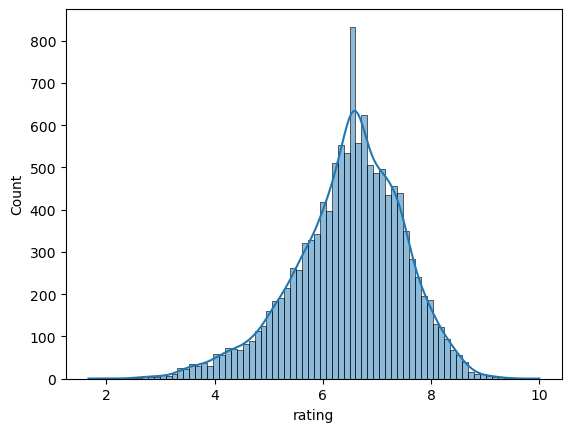

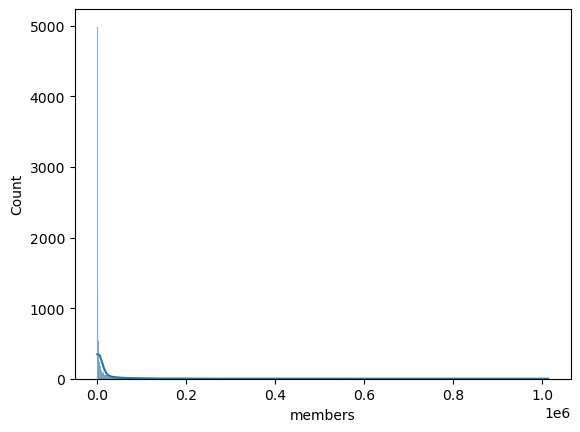

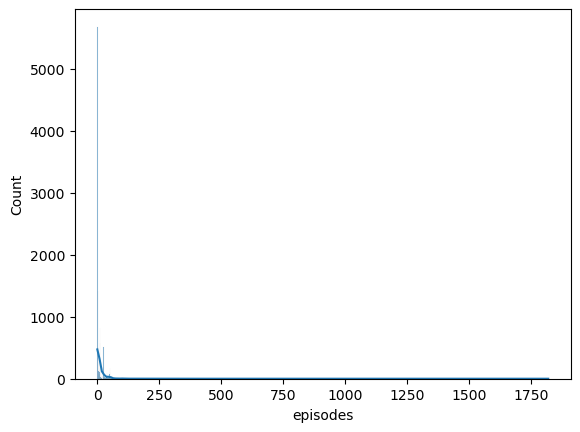

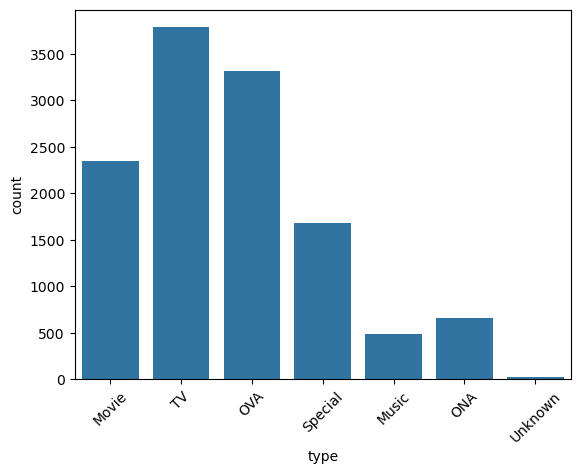

In [24]:
sns.histplot(anime['rating'],kde=True); plt.show()
sns.histplot(anime['members'],kde=True); plt.show()
sns.histplot(anime['episodes'],kde=True); plt.show()
sns.countplot(data=anime,x='type'); plt.xticks(rotation=45); plt.show()

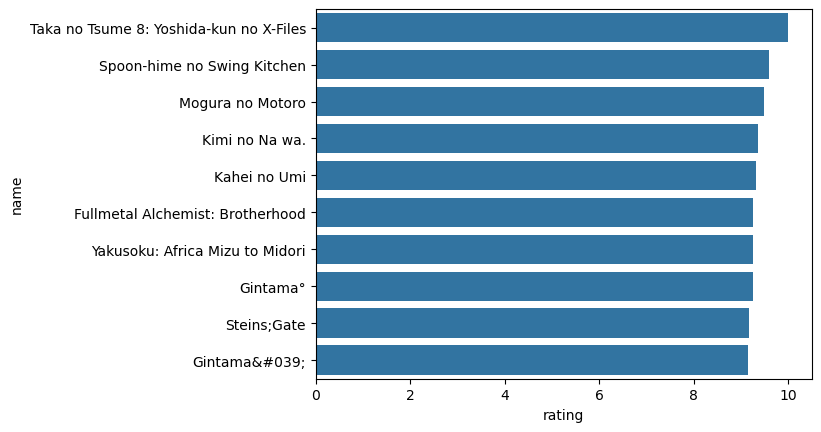

In [25]:
top=anime.sort_values('rating',ascending=False).head(10)
sns.barplot(data=top,x='rating',y='name'); plt.show()



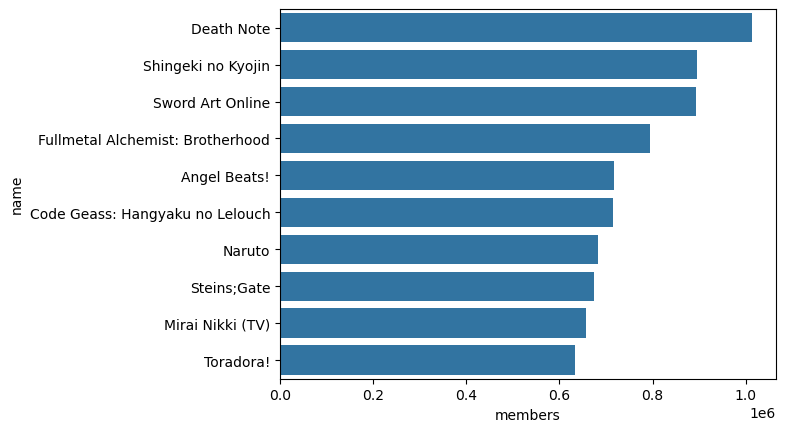

In [26]:
popular=anime.sort_values('members',ascending=False).head(10)
sns.barplot(data=popular,x='members',y='name'); plt.show()

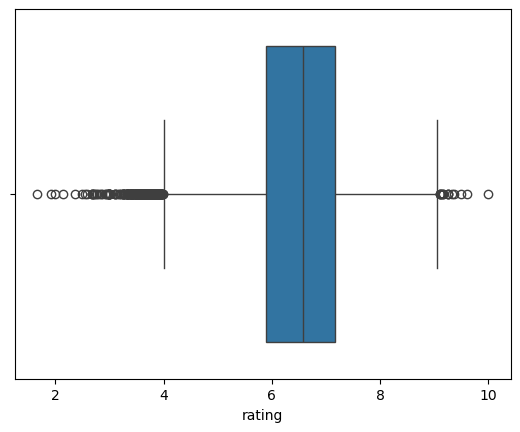

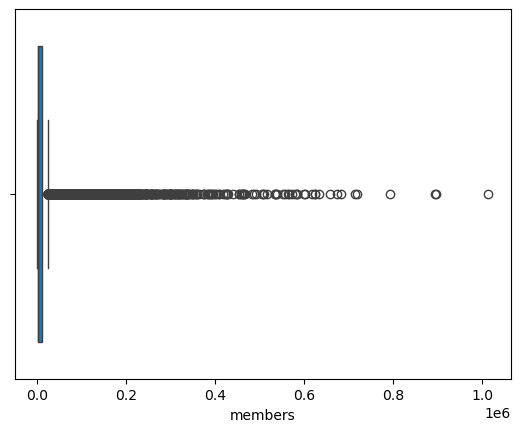

In [27]:
sns.boxplot(x=anime['rating']); plt.show()
sns.boxplot(x=anime['members']); plt.show()

# Rating: Detects high or low ratings (outliers).
# Members: Shows whether a few anime have large fan bases compared to the rest. This variable is highly right-skewed

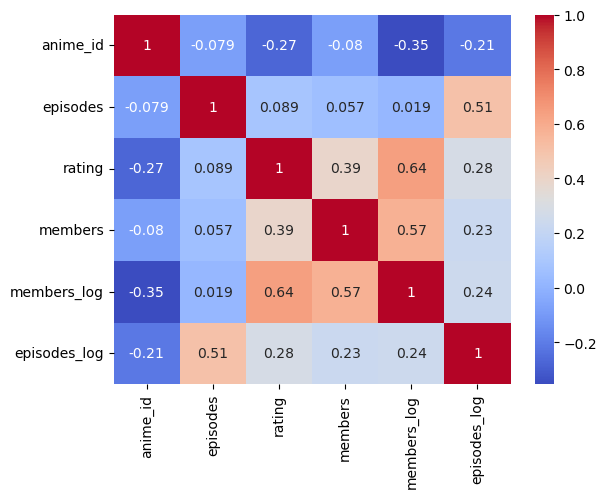

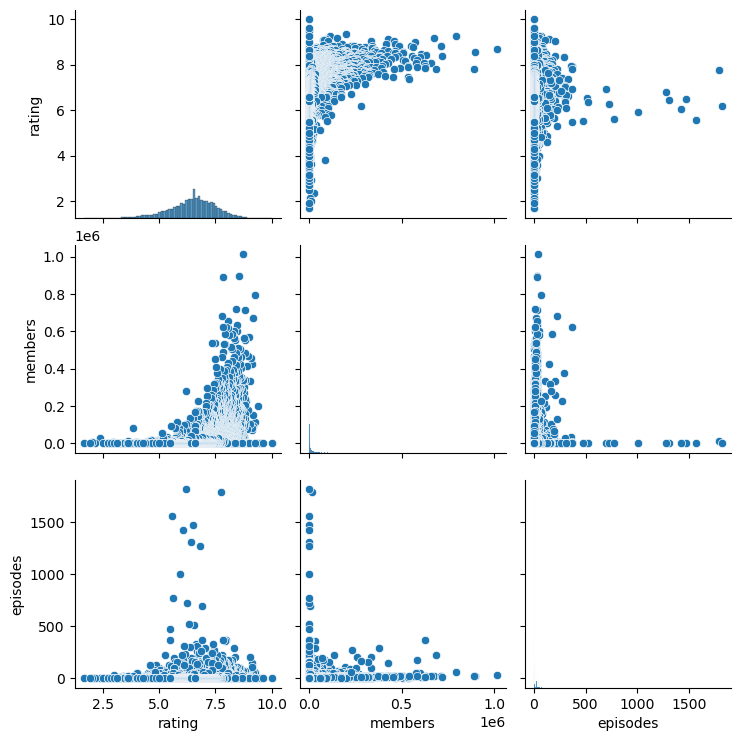

In [35]:
num=anime.select_dtypes(include=np.number)
sns.heatmap(num.corr(),annot=True,cmap='coolwarm'); plt.show()
sns.pairplot(anime[['rating','members','episodes']]); plt.show()


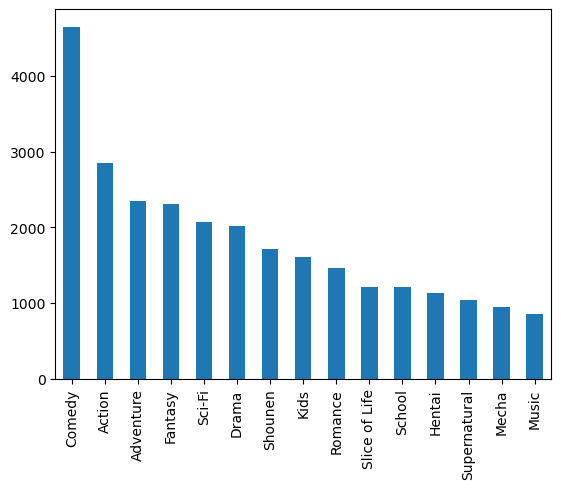

In [36]:
genres=[]
for g in anime['genre'].dropna():
    genres.extend([x.strip() for x in g.split(',')])
pd.Series(genres).value_counts().head(15).plot(kind='bar')
plt.show()

# Log transformation for skewed variables

In [37]:
print(num.skew())
anime['members_log']=np.log1p(anime['members'])
anime['episodes_log']=np.log1p(anime['episodes'])

anime_id         0.441550
episodes        23.685908
rating          -0.553879
members          6.682934
members_log      0.266096
episodes_log     1.053522
dtype: float64


# Cosine Similarity Computation
# IDF Feature Extraction

In [40]:
anime['content']=anime['genre'].astype(str)+' '+anime['type'].astype(str)
tfidf=TfidfVectorizer(stop_words='english')
tfidf_matrix=tfidf.fit_transform(anime['content'])
cosine_sim=cosine_similarity(tfidf_matrix)
indices=pd.Series(anime.index,index=anime['name']).drop_duplicates()

# Content-Based Recommendation System

In [41]:
def recommend(title,n=10):
    idx=indices[title]
    scores=list(enumerate(cosine_sim[idx]))
    scores=sorted(scores,key=lambda x:x[1],reverse=True)[1:n+1]
    idxs=[i[0] for i in scores]
    return anime[['name','genre','type','rating']].iloc[idxs]


In [33]:
print(recommend('Naruto'))

                                                   name  \
841                                              Naruto   
1343                                        Naruto x UT   
1796                                     Rekka no Honoo   
486                            Boruto: Naruto the Movie   
1472        Naruto: Shippuuden Movie 4 - The Lost Tower   
1573  Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsu...   
2997  Naruto Soyokazeden Movie: Naruto to Mashin to ...   
2342                             Kurokami The Animation   
2852                                       Project ARMS   
6163                                          Wolverine   

                                                  genre   type  rating  
841   Action, Comedy, Martial Arts, Shounen, Super P...     TV    7.81  
1343  Action, Comedy, Martial Arts, Shounen, Super P...    OVA    7.58  
1796  Action, Adventure, Martial Arts, Shounen, Supe...     TV    7.44  
486   Action, Comedy, Martial Arts, Shounen, Super P...  M